In [6]:
import matplotlib.pyplot as plt
import torch
import math

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_points = 1_000_000
num_iterations = 8
dtype = torch.float64

In [8]:
# Grid on [0, 1]
x = torch.linspace(0.0, 1.0, num_points, device=device, dtype=torch.float64)

# Keep track of surviving points for each iteration
# Shape: (num_iterations, num_points)
cantor_iterations = torch.empty((num_iterations, num_points), device=device, dtype=torch.bool)

# Iteratively extract the n-th ternary digit: floor(x * 3^k) % 3
scaled_x = x.clone()
in_cantor = torch.ones(num_points, device=device, dtype=torch.bool)

for k in range(num_iterations):
    # Shift base-3 fraction: multiply by 3 and extract the integer digit
    scaled_x = scaled_x * 3.0
    digit = torch.floor(scaled_x).to(torch.int64) % 3
    
    # Points with digit == 1 are in the removed middle third
    in_cantor = in_cantor & (digit != 1)
    cantor_iterations[k] = in_cantor
    
    # Retain fractional part for numerical stability
    scaled_x = scaled_x - torch.floor(scaled_x)

In [9]:
# Standard construction:
# c(x) = sum_{k=1}^K b_k / 2^k
# where b_k = 0 if digit == 0, b_k = 1 if digit >= 1 (clamped after first digit == 1)
scaled_x = x.clone()
cantor_func = torch.zeros(num_points, device=device, dtype=torch.float64)
has_seen_one = torch.zeros(num_points, device=device, dtype=torch.bool)

for k in range(1, num_iterations + 1):
    scaled_x = scaled_x * 3.0
    digit = torch.floor(scaled_x).to(torch.int64) % 3
    
    # Once a digit is 1, all subsequent effective binary digits become 0
    # and the current binary digit is set to 1.
    active = ~has_seen_one
    is_one = (digit == 1) & active
    is_two = (digit == 2) & active
    
    # Binary coefficient b_k
    b_k = torch.zeros(num_points, device=device, dtype=torch.float64)
    b_k[is_one | is_two] = 1.0
    
    cantor_func += b_k / (2.0 ** k)
    
    # Lock points that hit digit 1
    has_seen_one = has_seen_one | is_one
    scaled_x = scaled_x - torch.floor(scaled_x)

# Transfer results to CPU for visualization
x_cpu = x.cpu().numpy()
cantor_func_cpu = cantor_func.cpu().numpy()
cantor_set_cpu = cantor_iterations.cpu().numpy()

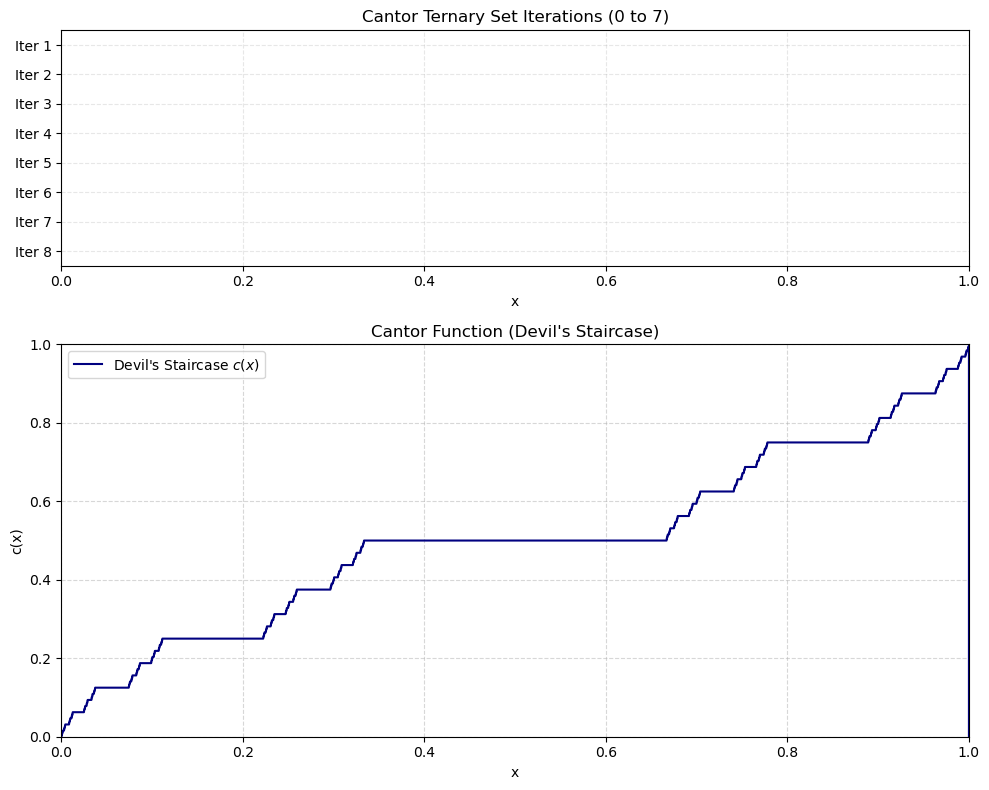

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1.2, 2]})

# Plot Cantor Set Iterations
for k in range(num_iterations):
    y_level = num_iterations - k
    mask = cantor_set_cpu[k]
    ax1.scatter(
        x_cpu[mask], 
        [y_level] * mask.sum(), 
        s=0.5, 
        c='black', 
        marker='|', 
        linewidths=0.5
    )

ax1.set_title(f"Cantor Ternary Set Iterations (0 to {num_iterations - 1})", fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_ylim(0.5, num_iterations + 0.5)
ax1.set_yticks(range(1, num_iterations + 1))
ax1.set_yticklabels([f"Iter {num_iterations - i}" for i in range(num_iterations)])
ax1.set_xlabel("x")
ax1.grid(True, linestyle="--", alpha=0.3)

# Plot Devil's Staircase
ax2.plot(x_cpu, cantor_func_cpu, color="navy", lw=1.5, label="Devil's Staircase $c(x)$")
ax2.set_title("Cantor Function (Devil's Staircase)", fontsize=12)
ax2.set_xlabel("x")
ax2.set_ylabel("c(x)")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [11]:
def generate_cantor_set(num_points: int = 1_000_000, iterations: int = 10):
    """
    Generates points surviving in the Cantor ternary set after a given number of iterations.
    """
    x = torch.linspace(0.0, 1.0, num_points, device=device, dtype=dtype)
    scaled_x = x.clone()
    in_cantor = torch.ones(num_points, device=device, dtype=torch.bool)

    for _ in range(iterations):
        scaled_x = scaled_x * 3.0
        digit = torch.floor(scaled_x).to(torch.int64) % 3
        in_cantor = in_cantor & (digit != 1)
        scaled_x = scaled_x - torch.floor(scaled_x)

    return x[in_cantor]

In [12]:
def compute_box_dimension(points: torch.Tensor, max_depth: int = 8):
    """
    Computes theoretical dimension ln(2)/ln(3) and calculates the empirical
    box-counting dimension via log-log linear regression on GPU.
    """
    theoretical_dim = math.log(2.0) / math.log(3.0)

    scales = []
    box_counts = []

    for k in range(1, max_depth + 1):
        eps = 1.0 / (3.0**k)
        # Map points into discrete box indices: floor(x / eps)
        box_indices = torch.floor(points / eps).to(torch.int64)
        # Count non-empty unique intervals
        num_occupied = torch.unique(box_indices).numel()

        scales.append(1.0 / eps)
        box_counts.append(num_occupied)

    log_inv_eps = torch.log(torch.tensor(scales, device=device, dtype=dtype))
    log_n = torch.log(torch.tensor(box_counts, device=device, dtype=dtype))

    # Linear regression: log(N(eps)) = D * log(1/eps) + C via PyTorch least squares
    A = torch.stack([log_inv_eps, torch.ones_like(log_inv_eps)], dim=1)
    solution = torch.linalg.lstsq(A, log_n).solution
    empirical_dim = solution[0].item()

    return theoretical_dim, empirical_dim, log_inv_eps.cpu(), log_n.cpu()

In [13]:
def compute_devils_staircase(x: torch.Tensor, iterations: int):
    """
    Computes the Cantor function c_k(x) up to a specified number of iterations.
    """
    num_pts = x.shape[0]
    scaled_x = x.clone()
    cantor_func = torch.zeros(num_pts, device=device, dtype=dtype)
    has_seen_one = torch.zeros(num_pts, device=device, dtype=torch.bool)

    for k in range(1, iterations + 1):
        scaled_x = scaled_x * 3.0
        digit = torch.floor(scaled_x).to(torch.int64) % 3

        active = ~has_seen_one
        is_one = (digit == 1) & active
        is_two = (digit == 2) & active

        b_k = torch.zeros(num_pts, device=device, dtype=dtype)
        b_k[is_one | is_two] = 1.0

        cantor_func += b_k / (2.0**k)

        has_seen_one = has_seen_one | is_one
        scaled_x = scaled_x - torch.floor(scaled_x)

    return cantor_func


def analyze_convergence(max_iters: int = 15, num_points: int = 1_000_000):
    """
    Evaluates uniform (L_inf) and mean-squared (L_2) convergence errors
    of c_k(x) relative to reference c_max(x).
    """
    x = torch.linspace(0.0, 1.0, num_points, device=device, dtype=dtype)

    # Compute high-fidelity reference curve at max_iters
    ref_curve = compute_devils_staircase(x, max_iters)

    l_inf_errors = []
    l_2_errors = []
    iterations = list(range(1, max_iters))

    for k in iterations:
        c_k = compute_devils_staircase(x, k)
        error = torch.abs(c_k - ref_curve)

        l_inf = torch.max(error).item()
        l_2 = torch.sqrt(torch.mean(error**2)).item()

        l_inf_errors.append(l_inf)
        l_2_errors.append(l_2)

    return iterations, l_inf_errors, l_2_errors

Theoretical Box Dimension : 0.630930
Empirical Box Dimension   : 0.580761
Absolute Estimation Error : 5.016913e-02


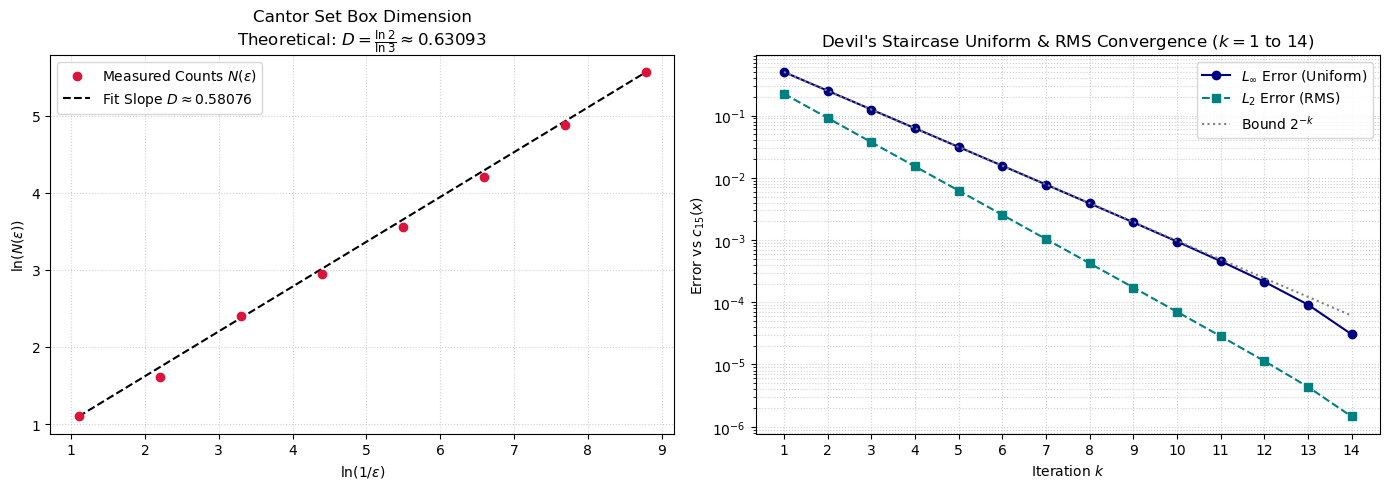

In [14]:
if __name__ == "__main__":
    num_pts = 1_000_000

    # 1. Fractal dimension calculation
    cantor_pts = generate_cantor_set(num_points=num_pts, iterations=10)
    theo_dim, emp_dim, log_inv_eps, log_n = compute_box_dimension(
        cantor_pts, max_depth=8
    )

    print(f"Theoretical Box Dimension : {theo_dim:.6f}")
    print(f"Empirical Box Dimension   : {emp_dim:.6f}")
    print(f"Absolute Estimation Error : {abs(emp_dim - theo_dim):.6e}")

    # 2. Convergence evaluation (Iterations 1 to 15)
    iters, l_inf_errs, l_2_errs = analyze_convergence(
        max_iters=15, num_points=num_pts
    )

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Box-counting log-log regression fit
    ax1.scatter(
        log_inv_eps,
        log_n,
        color="crimson",
        label=f"Measured Counts $N(\\epsilon)$",
        zorder=3,
    )
    # Regression line
    fit_line = emp_dim * log_inv_eps + (log_n[0] - emp_dim * log_inv_eps[0])
    ax1.plot(
        log_inv_eps,
        fit_line,
        color="black",
        linestyle="--",
        label=f"Fit Slope $D \\approx {emp_dim:.5f}$",
    )
    ax1.set_title(
        f"Cantor Set Box Dimension\nTheoretical: $D = \\frac{{\\ln 2}}{{\\ln 3}} \\approx {theo_dim:.5f}$"
    )
    ax1.set_xlabel("$\\ln(1/\\epsilon)$")
    ax1.set_ylabel("$\\ln(N(\\epsilon))$")
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend()

    # Plot 2: Convergence Error vs Iterations (Semilog-Y)
    ax2.semilogy(
        iters,
        l_inf_errs,
        marker="o",
        color="navy",
        label="$L_\\infty$ Error (Uniform)",
    )
    ax2.semilogy(
        iters,
        l_2_errs,
        marker="s",
        color="teal",
        linestyle="--",
        label="$L_2$ Error (RMS)",
    )

    # Theoretical upper bound: ||c_k - c||_inf <= 2^(-k)
    theo_bound = [2.0 ** (-k) for k in iters]
    ax2.semilogy(
        iters,
        theo_bound,
        color="gray",
        linestyle=":",
        label="Bound $2^{-k}$",
    )

    ax2.set_title("Devil's Staircase Uniform & RMS Convergence ($k=1$ to $14$)")
    ax2.set_xlabel("Iteration $k$")
    ax2.set_ylabel("Error vs $c_{15}(x)$")
    ax2.set_xticks(iters)
    ax2.grid(True, which="both", linestyle=":", alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()